## Author: Chan Jin Wei
---

In [8]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from classes.dataframe_saver import DataFrameSaver
from classes.morphological_analysis import MorphologicalAnalysis
import subprocess

In [9]:
subprocess.run(['hdfs', 'dfs', '-rm', 'dictionary2/*'])

Deleted dictionary2/_SUCCESS
Deleted dictionary2/dictionary2.csv


CompletedProcess(args=['hdfs', 'dfs', '-rm', 'dictionary2/*'], returncode=0)

In [10]:
spark = SparkSession.builder.appName("morphologicalAnalysis").master("local").getOrCreate()

input_file = 'dictionary1/dictionary1.csv'
local_output_dir = '/home/student/de-assgt/content'
local_file_name = 'dictionary2.csv'
hdfs_path = "dictionary2"

df = spark.read.csv(input_file, header=True, inferSchema=True)

df_updated = MorphologicalAnalysis.process_dataframe(df)

DataFrameSaver.save_to_csv(df_updated, local_output_dir, local_file_name)


24/12/22 13:11:28 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [11]:
df_updated.show()

+------------+--------------------+---------+-----------+----------+--------------------+--------------+
|       words|          definition|  pos_tag|freq_of_use|kata_dasar|       kata_terbitan|num_variations|
+------------+--------------------+---------+-----------+----------+--------------------+--------------+
|     perdana|[per.da.na]  Defi...|        -|          -|         -|                   -|             0|
|       datuk|[da.tu]  Definisi...|        -|          -|         -|                   -|             0|
|       anwar|                   -|        -|          -|         -|                   -|             0|
|     ibrahim|                   -|        -|          -|         -|                   -|             0|
|        hari|[ha.ri]  Definisi...|        -|          -|      hari|sehari-hari, seha...|             4|
|         ini|[i.ni]  Definisi ...|        -|          -|         -|                   -|             0|
|  mengadakan|[me.nga.da.kan]  ...|        -|          

In [12]:
df_updated.coalesce(1).write.csv(hdfs_path, header=True, mode="overwrite")
print(f"Content saved to HDFS at: {hdfs_path}")

Content saved to HDFS at: dictionary2


In [13]:
subprocess.run(['hdfs', 'dfs', '-mv', 'dictionary2/part-00000*', 'dictionary2/dictionary2.csv'])

CompletedProcess(args=['hdfs', 'dfs', '-mv', 'dictionary2/part-00000*', 'dictionary2/dictionary2.csv'], returncode=0)

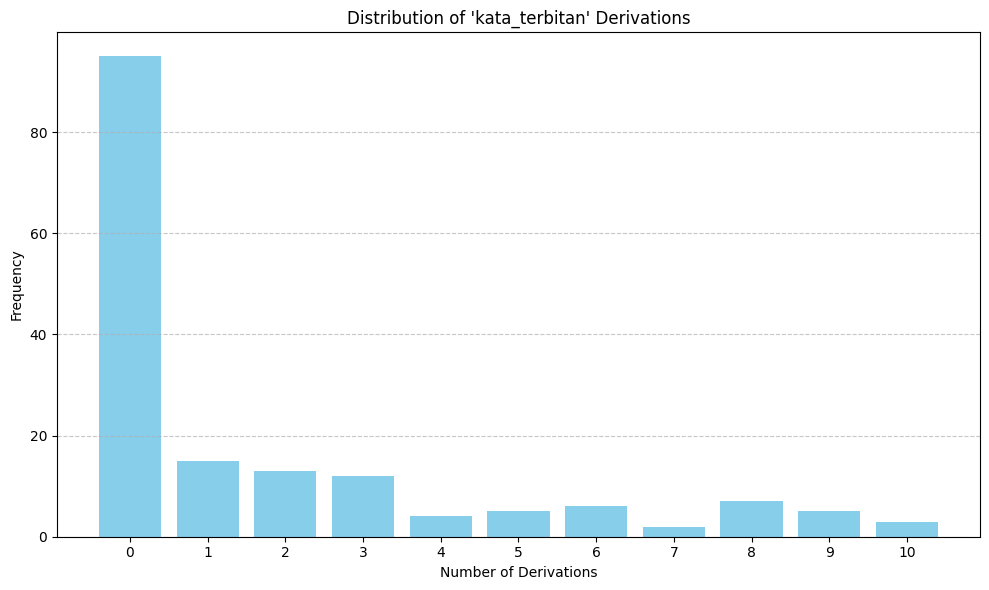

Number of words with no 'kata_terbitan' : 95
Number of words with 'kata_terbitan' : 72

Words with the highest number of 'kata_terbitan' derivations (10):


+------+-------------------------------------------------------------------------------------------------------------------+--------------+
|words |kata_terbitan                                                                                                      |num_variations|
+------+-------------------------------------------------------------------------------------------------------------------+--------------+
|tuju  |bersetuju, mempersetujui, menyetujukan, mempersetujukan, persetujuan, menuju, menujui, menujukan, tujuan, bertujuan|10            |
|ulasan|berulas, mengulas, ulas2, seulas, berulas, ulas3, mengulas, ulasan, pengulasan, pengulas                           |10            |
|tuju  |bersetuju, mempersetujui, menyetujukan, mempersetujukan, persetujuan, menuju, menujui, menujukan, tujuan, bertujuan|10            |
+------+-------------------------------------------------------------------------------------------------------------------+--------------+

Original data frame

+------------+--------------------+---------+-----------+----------+--------------------+--------------+
|       words|          definition|  pos_tag|freq_of_use|kata_dasar|       kata_terbitan|num_variations|
+------------+--------------------+---------+-----------+----------+--------------------+--------------+
|     perdana|[per.da.na]  Defi...|        -|          -|         -|                   -|             0|
|       datuk|[da.tu]  Definisi...|        -|          -|         -|                   -|             0|
|       anwar|                   -|        -|          -|         -|                   -|             0|
|     ibrahim|                   -|        -|          -|         -|                   -|             0|
|        hari|[ha.ri]  Definisi...|        -|          -|      hari|sehari-hari, seha...|             4|
|         ini|[i.ni]  Definisi ...|        -|          -|         -|                   -|             0|
|  mengadakan|[me.nga.da.kan]  ...|        -|          

In [15]:
MorphologicalAnalysis.summary(df_updated)

In [14]:
spark.stop()